In [1]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()

/tmp/ipykernel_1799/536094589.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


Trades Shape: (46482, 16)
Sentiment Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [2]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [6]:
merged = pd.merge(
    trades,
    sentiment[['date','classification','value']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


Profitability vs Market Sentiment


In [7]:
merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)


,Closed PnL
classification,
Extreme Fear,204.336799
Extreme Greed,162.746010
Fear,146.672879
Greed,92.228518
Neutral,86.191512


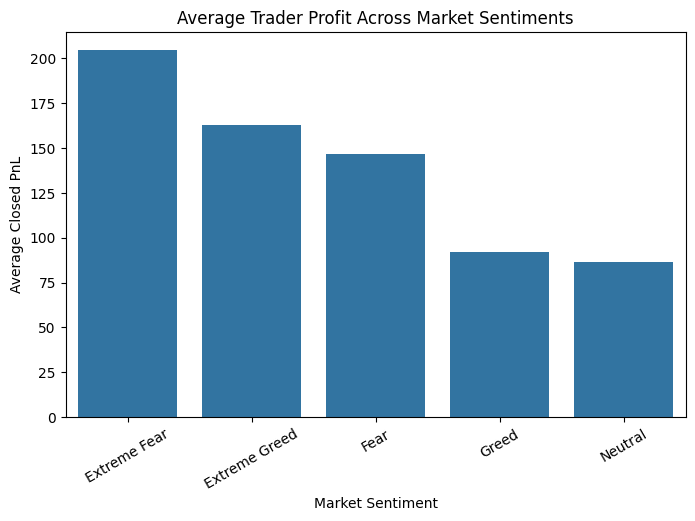

In [11]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=avg_pnl, x='classification', y='Closed PnL')
plt.title("Average Trader Profit Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=30)
plt.show()

In [8]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,
Extreme Fear,3.567721e+05
Extreme Greed,1.522489e+06
Fear,1.776795e+06
Greed,1.398738e+06
Neutral,6.977203e+05


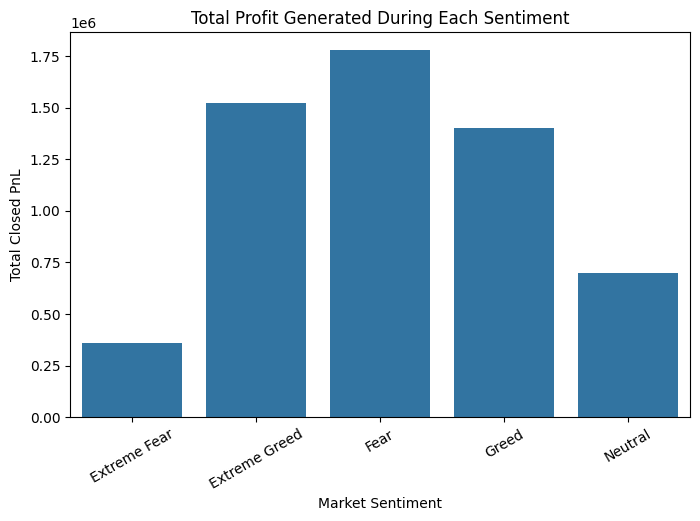

In [12]:
total_pnl = merged.groupby('classification')['Closed PnL'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=total_pnl, x='classification', y='Closed PnL')
plt.title("Total Profit Generated During Each Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=30)
plt.show()

In [9]:
merged['classification'].value_counts()

,count
classification,
Greed,15166
Fear,12114
Extreme Greed,9355
Neutral,8095
Extreme Fear,1746


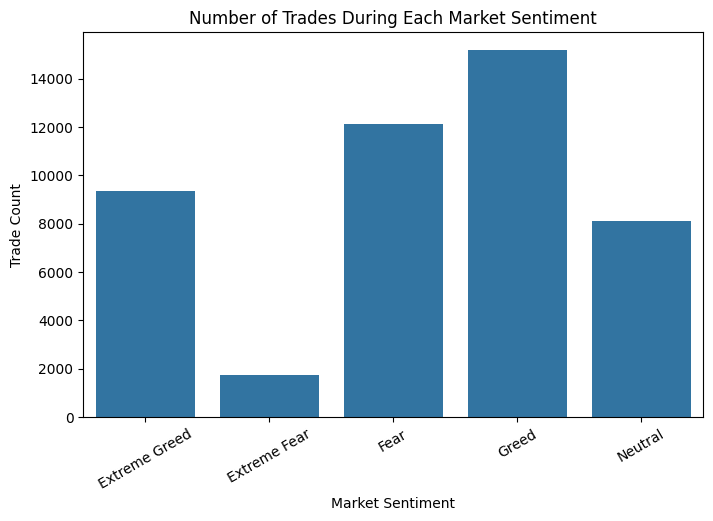

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged, x='classification')
plt.title("Number of Trades During Each Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=30)
plt.show()

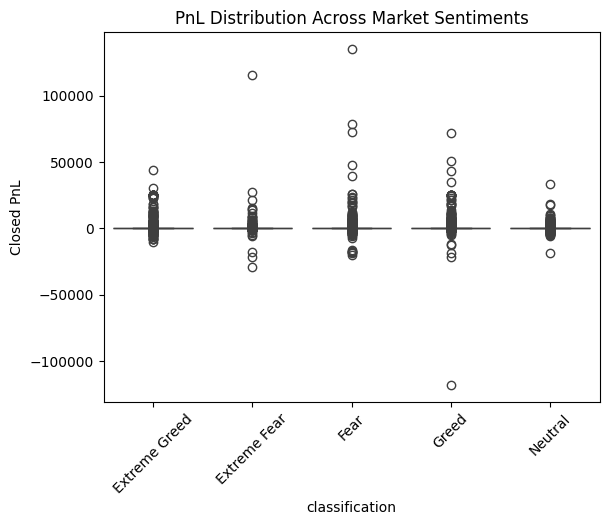

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution Across Market Sentiments")
plt.xticks(rotation=45)
plt.show()

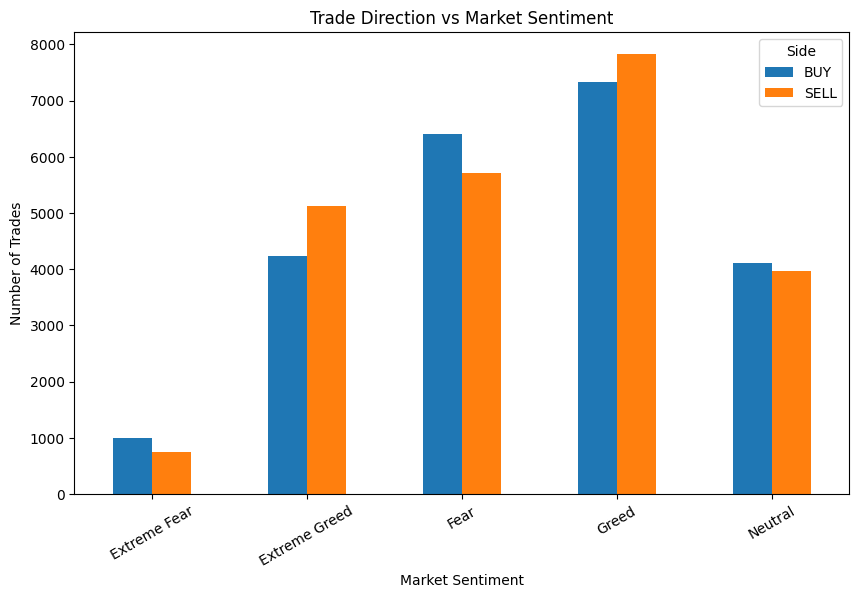

In [14]:
direction_sentiment = merged.groupby(['classification','Side']).size().unstack()

direction_sentiment.plot(kind='bar', figsize=(10,6))

plt.title("Trade Direction vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=30)
plt.show()

In [15]:
merged['is_profit'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['is_profit'].mean() * 100

print(win_rate)

classification
Extreme Fear     40.492554
Extreme Greed    53.693212
Fear             44.502229
Greed            41.131478
Neutral          47.906115
Name: is_profit, dtype: float64


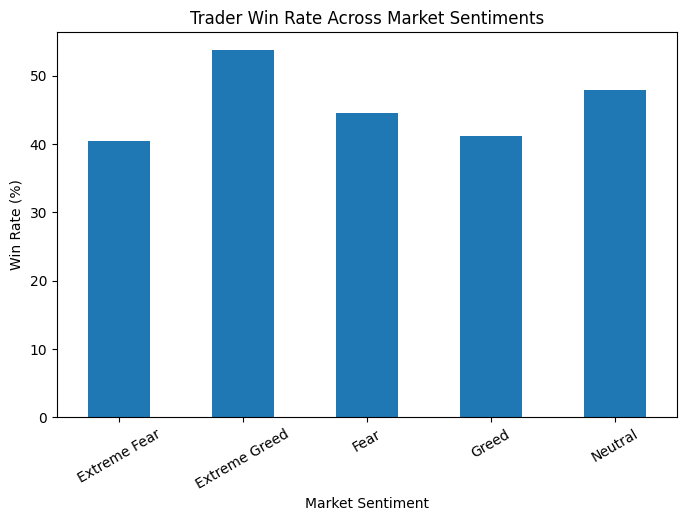

In [16]:
win_rate.plot(kind='bar', figsize=(8,5))
plt.title("Trader Win Rate Across Market Sentiments")
plt.ylabel("Win Rate (%)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=30)
plt.show()

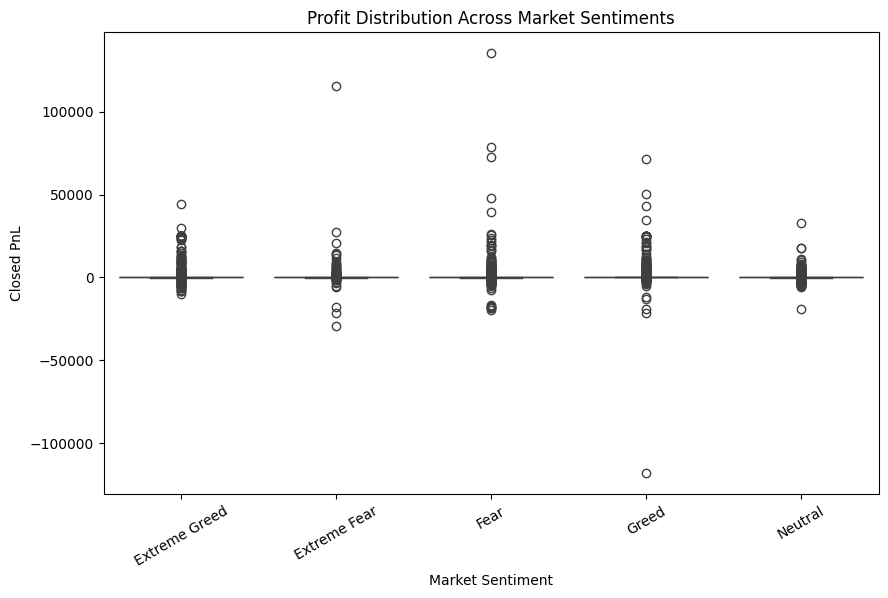

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("Profit Distribution Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=30)

plt.show()

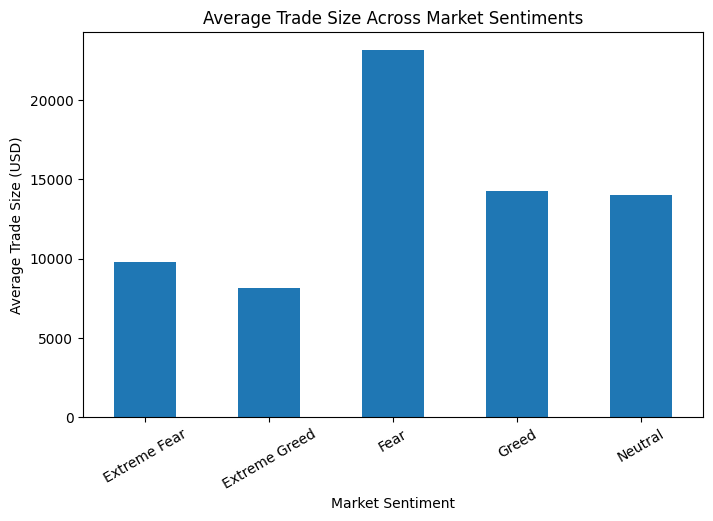

In [18]:
size_analysis = merged.groupby('classification')['Size USD'].mean()

plt.figure(figsize=(8,5))
size_analysis.plot(kind='bar')

plt.title("Average Trade Size Across Market Sentiments")
plt.ylabel("Average Trade Size (USD)")
plt.xlabel("Market Sentiment")

plt.xticks(rotation=30)

plt.show()